# 06 - Decision Trees

In [2]:
# data = "https://raw.githubusercontent.com/gastonstat/CreditScoring/refs/heads/master/CreditScoring.csv"

In [3]:
# !wget $data

In [4]:
# !head CreditScoring.csv

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

## Data Cleaning

In [6]:
df = pd.read_csv("CreditScoring.csv")
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [7]:
df.columns = df.columns.str.lower()
df.columns

Index(['status', 'seniority', 'home', 'time', 'age', 'marital', 'records',
       'job', 'expenses', 'income', 'assets', 'debt', 'amount', 'price'],
      dtype='str')

In [8]:
status_values={1:'ok', 2: 'default', 0: 'unk'}
df.status = df.status.map(status_values)

In [9]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,1,60,30,2,1,3,73,129,0,0,800,846
1,ok,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,default,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,ok,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,ok,0,1,36,26,1,1,1,46,107,0,0,310,910


In [10]:
home_val = {
    1: "rent",
    2: "owner",
    3: "priv",
    4: "ignore",
    5: "parents",
    6: "other",
    0: 'unk'
}

marital_val = {
    1: 'single', 
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'ukn'
}

records_val = {
    1: 'no',
    2:'yes',
    0:'unk'
}

job_val = {
    1:'fixed',
    2:'partime',
    3:'freelance',
    4:'others',
    0:'unk'
}

df.home = df.home.map(home_val)
df.marital = df.marital.map(marital_val)
df.records = df.records.map(records_val)
df.job = df.job.map(job_val)

In [11]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910


In [12]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [13]:
for c in ['income', 'assets', 'debt']:
    df[c] = df[c].replace(to_replace=99999999, value=np.nan)

df.describe()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.000000,4455.000000,4455.000000,4455.000000,4421.000000,4408.000000,4437.000000,4455.000000,4455.000000
mean,7.987205,46.441751,37.077666,55.568799,130.568197,5403.433984,342.948614,1039.021773,1462.875645
std,8.173444,14.655225,10.984856,19.515878,86.367434,11573.161523,1245.861736,474.543007,628.089913
min,0.000000,6.000000,18.000000,35.000000,0.000000,0.000000,0.000000,100.000000,105.000000
25%,2.000000,36.000000,28.000000,35.000000,80.000000,0.000000,0.000000,700.000000,1117.500000
50%,5.000000,48.000000,36.000000,51.000000,120.000000,3000.000000,0.000000,1000.000000,1400.000000
75%,12.000000,60.000000,45.000000,72.000000,165.000000,6000.000000,0.000000,1300.000000,1692.000000
max,48.000000,72.000000,68.000000,180.000000,959.000000,300000.000000,30000.000000,5000.000000,11140.000000


In [14]:
df = df[df.status != 'unk'].reset_index(drop=True)

In [15]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df,test_size = 0.2, random_state =11)
df_train, df_val = train_test_split(df, test_size=0.25, random_state = 11)

In [16]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [17]:
y_train = (df_train.status == 'default').astype('int').values
y_val = (df_val.status == 'default').astype('int').values
y_test = (df_test.status == 'default').astype('int').values

In [18]:
del df_train['status']
del df_val['status']
del df_test['status']

In [19]:
df_train.head()

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,rent,36,24,married,no,partime,41,56.0,0.0,0.0,500,585
1,1,owner,60,24,single,no,fixed,35,70.0,4000.0,0.0,1200,1505
2,5,parents,36,45,married,yes,fixed,75,68.0,0.0,0.0,2375,2875
3,13,owner,60,27,married,no,fixed,60,112.0,3000.0,1485.0,800,1200
4,9,other,36,32,single,no,fixed,35,125.0,0.0,0.0,1000,1725


## Decision Trees

In [20]:
def assets_risk(client):
    if client['records'] == 'yes':
        if client['job'] == 'partime':
            return 'default'
        else:
            return 'ok'
    else:
        if client['assets'] > 6000:
            return 'ok'
        else:
            return 'default'

In [21]:
xi = df_train.iloc[0].to_dict()
xi

{'seniority': 1,
 'home': 'rent',
 'time': 36,
 'age': 24,
 'marital': 'married',
 'records': 'no',
 'job': 'partime',
 'expenses': 41,
 'income': 56.0,
 'assets': 0.0,
 'debt': 0.0,
 'amount': 500,
 'price': 585}

In [22]:
assets_risk(xi)

'default'

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [24]:
train_dicts = df_train.fillna(0).to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [25]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)


In [27]:
y_pred = dt.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
print('val', auc)
y_pred = dt.predict_proba(X_train)[:,1]
auc= roc_auc_score(y_train, y_pred)
print('train', auc)

val 0.6676232454537954
train 1.0


In [28]:
from sklearn.tree import export_text

print(export_text(dt))

|--- feature_25 <= 0.50
|   |--- feature_27 <= 6.50
|   |   |--- feature_27 <= 1.50
|   |   |   |--- feature_2 <= 4750.00
|   |   |   |   |--- feature_3 <= 260.00
|   |   |   |   |   |--- feature_24 <= 537.50
|   |   |   |   |   |   |--- feature_27 <= 0.50
|   |   |   |   |   |   |   |--- feature_13 <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- feature_13 >  0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- feature_27 >  0.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_24 >  537.50
|   |   |   |   |   |   |--- feature_0 <= 23.50
|   |   |   |   |   |   |   |--- feature_8 <= 0.50
|   |   |   |   |   |   |   |   |--- feature_27 <= 0.50
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- feature_27 >  0.50
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- feature_8 >  0.50
|   |   |   |   |   |   |   |   |--- class: 1
|  

**This is overfitting** 

this means that the model has memorized the training data and when a validation data is given to it, its performance is bad. 

The reason, in this case, is that the tree is too deep - do the model became too specific (in this case to the training data)
- the solution is too prune the tree and stablish a max depth - so it becomes more general

In [29]:
dt_w_max_depth = DecisionTreeClassifier(max_depth=2)
dt_w_max_depth.fit(X_train, y_train)
y_pred = dt_w_max_depth.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)
print('val', auc)
y_pred = dt_w_max_depth.predict_proba(X_train)[:,1]
auc= roc_auc_score(y_train, y_pred)
print('train', auc)


val 0.6624278637454675
train 0.6972613817060012


In [30]:
from sklearn.tree import export_text
print(export_text(dt_w_max_depth, feature_names = dv.get_feature_names_out()))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- class: 0
|--- records=no >  0.50
|   |--- job=partime <= 0.50
|   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- class: 1



## 3 & 4 Devision Tree learning alrgorithm

- finding the best split for one column
- finding the best split for the entire dataset
- stopping criteria
- Decision tree learning algorithm

#### 2 variables

In [31]:
data = [
    [8000, 'defautl'],
    [2000, 'default'],
    [   0, 'default'],
    [5000, 'ok'],
    [5000, 'ok'],
    [4000, 'ok'],
    [9000, 'ok'],
    [3000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'status'])
df_example

,assets,status
0,8000,defautl
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [32]:
df_example.sort_values('assets')

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,defautl
6,9000,ok


In [33]:
Ts = [0,2000,3000,4000,5000,8000]

In [34]:
from IPython.display import display

In [35]:
for T in Ts:
    print(T)
    df_left = df_example[df_example.assets<=T]
    df_right = df_example[df_example.assets>T]

    display(df_left)
    display(df_right)

    print()



0


,assets,status
2,0,default


,assets,status
0,8000,defautl
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default



2000


,assets,status
1,2000,default
2,0,default


,assets,status
0,8000,defautl
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default



3000


,assets,status
1,2000,default
2,0,default
7,3000,default


,assets,status
0,8000,defautl
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok



4000


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


,assets,status
0,8000,defautl
3,5000,ok
4,5000,ok
6,9000,ok



5000


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


,assets,status
0,8000,defautl
6,9000,ok



8000


,assets,status
0,8000,defautl
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


,assets,status
6,9000,ok


In [36]:
T = 4000
print(T)
df_left = df_example[df_example.assets<=T]
df_right = df_example[df_example.assets>T]

display(df_left)
display(df_right)

print()

print(df_left.status.value_counts(normalize=True))
print(df_right.status.value_counts(normalize=True))

4000


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


,assets,status
0,8000,defautl
3,5000,ok
4,5000,ok
6,9000,ok



status
default    0.75
ok         0.25
Name: proportion, dtype: float64
status
ok         0.75
defautl    0.25
Name: proportion, dtype: float64


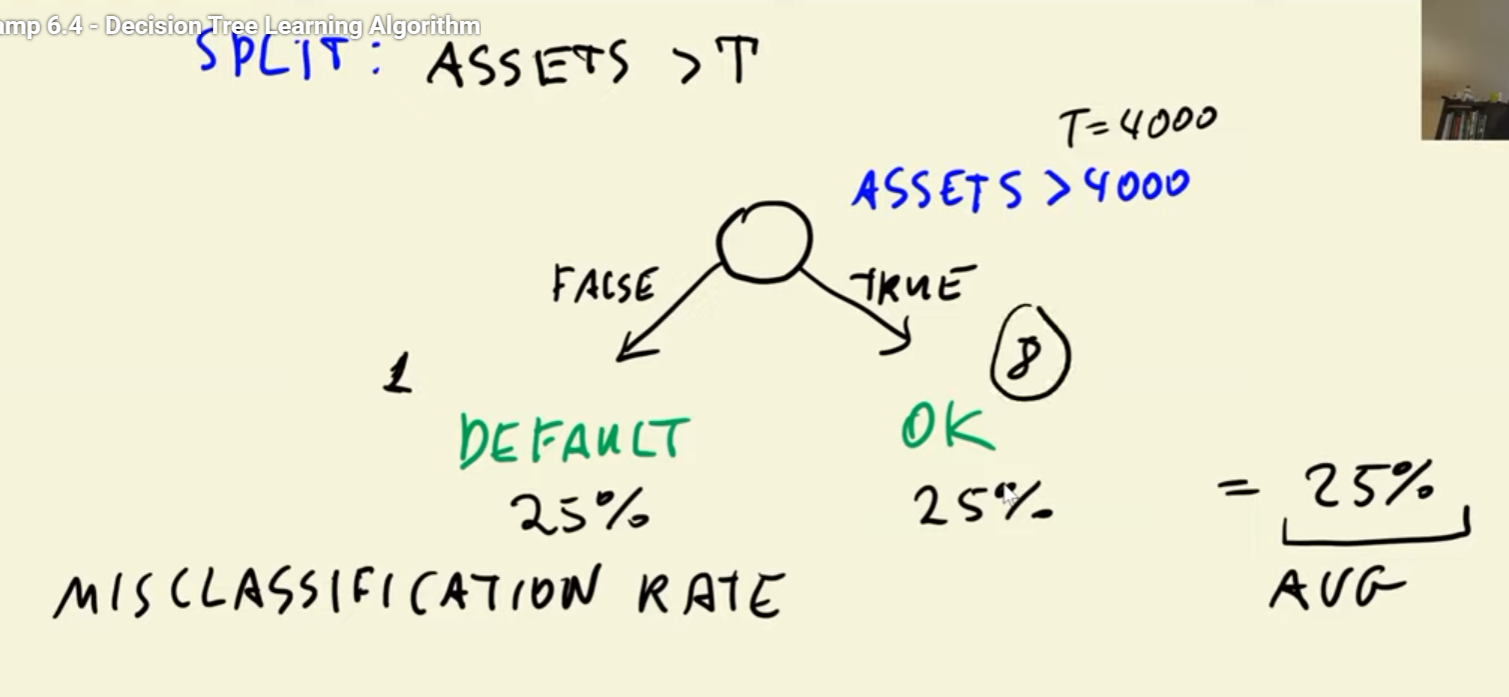

**misclassification rate = 25%**

****in trees this is a way (just one way to measure impurity)****

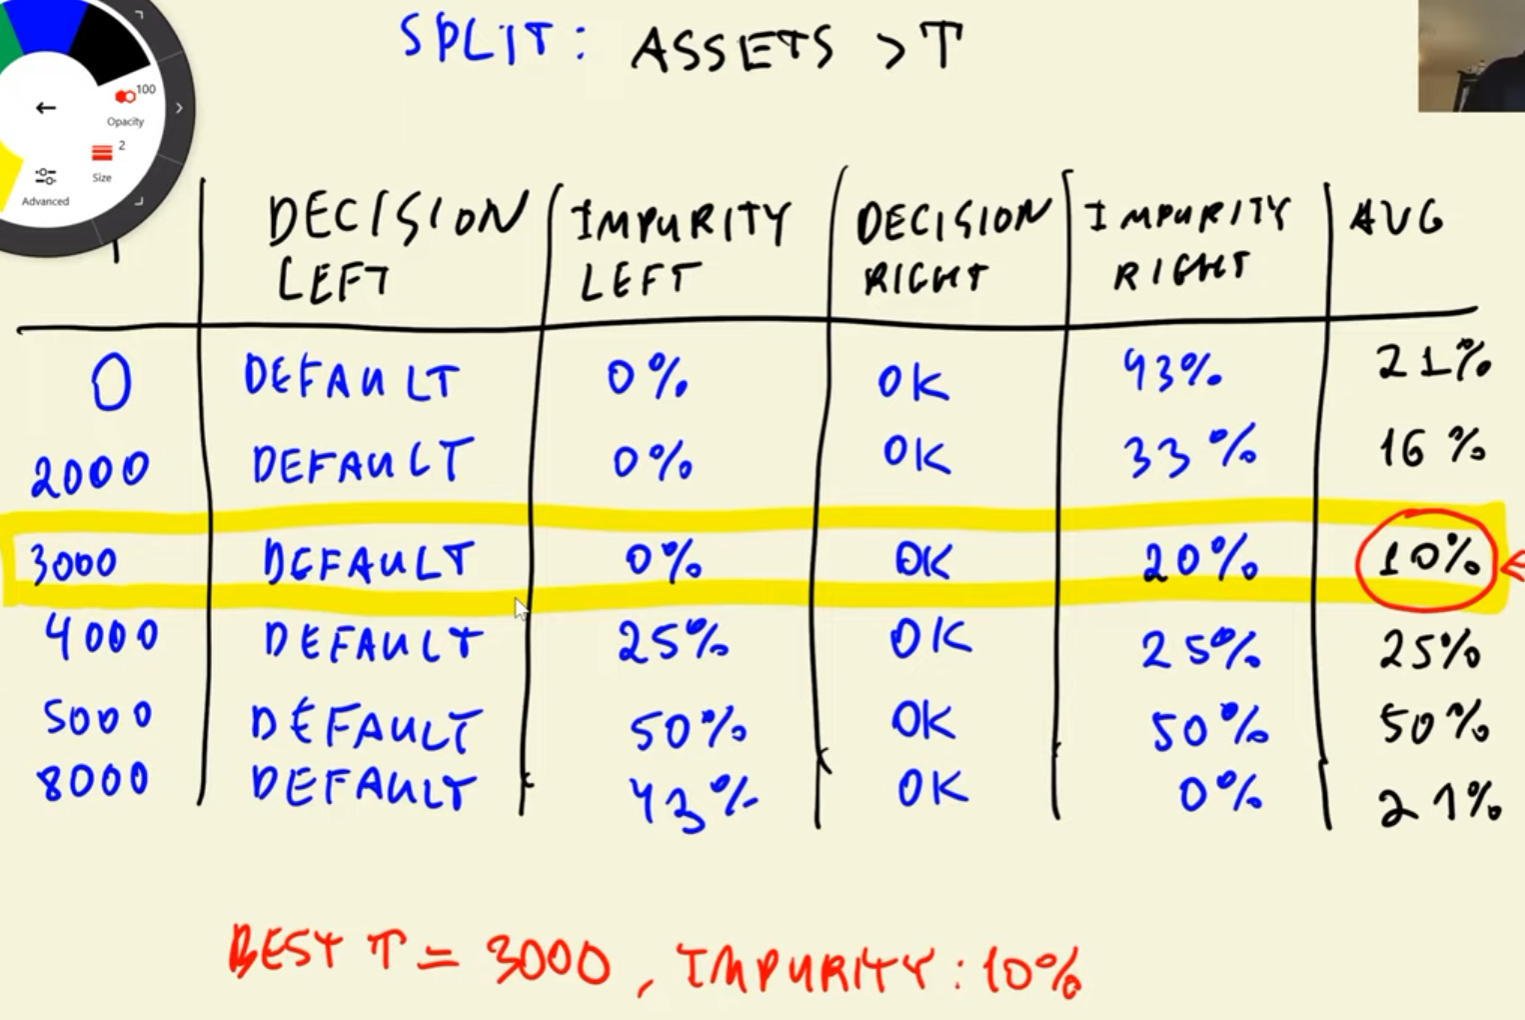

#### 3 variables

In [37]:
data = [
    [8000, 3000, 'default'],
    [2000, 1000, 'default'],
    [   0, 1000, 'default'],
    [5000, 1000, 'ok'],
    [5000, 1000, 'ok'],
    [4000, 1000, 'ok'],
    [9000, 500, 'ok'],
    [3000, 1000, 'default'],
]

df_example = pd.DataFrame(data, columns=['assets', 'debt', 'status'])
df_example

,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,1000,default


In [38]:
df_example.sort_values('debt')

,assets,debt,status
6,9000,500,ok
1,2000,1000,default
3,5000,1000,ok
2,0,1000,default
5,4000,1000,ok
4,5000,1000,ok
7,3000,1000,default
0,8000,3000,default


In [39]:
thresholds = {
    'assets': [0,2000,3000,4000,5000,8000],
    'debt':[500,1000,3000]}

In [40]:
for feature, Ts in thresholds.items():
    print('####################################################')
    print(feature)
    for T in Ts:
        print(T)
        df_left = df_example[df_example[feature]<=T]
        df_right = df_example[df_example[feature]>T]
        display(df_left)
        print(df_left.status.value_counts(normalize=True))
        display(df_right)
        print(df_right.status.value_counts(normalize=True))
        print()
    print('####################################################')

####################################################
assets
0


,assets,debt,status
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,1000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64

2000


,assets,debt,status
1,2000,1000,default
2,0,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,1000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64

3000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
7,3000,1000,default


status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64

4000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
5,4000,1000,ok
7,3000,1000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
6,9000,500,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64

5000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,1000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
6,9000,500,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64

8000


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,1000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64

####################################################
####################################################
debt
500


,assets,debt,status
6,9000,500,ok


status
ok    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,1000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64

1000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,1000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default


status
default    1.0
Name: proportion, dtype: float64

3000


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,1000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status


Series([], Name: proportion, dtype: float64)

####################################################


In [41]:
T = 4000
print(T)
df_left = df_example[df_example.assets<=T]
df_right = df_example[df_example.assets>T]

display(df_left)
display(df_right)

print()

print(df_left.status.value_counts(normalize=True))
print(df_right.status.value_counts(normalize=True))

4000


,assets,debt,status
1,2000,1000,default
2,0,1000,default
5,4000,1000,ok
7,3000,1000,default


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
6,9000,500,ok



status
default    0.75
ok         0.25
Name: proportion, dtype: float64
status
ok         0.75
default    0.25
Name: proportion, dtype: float64


## 5 Decision Tree parameter tuning
- Selecting max_depth
- selecting min_samples_leaf

In [42]:
from sklearn.tree import DecisionTreeClassifier

for d in [1,2,3,4,5,6,10,15,20,None]:
    dt = DecisionTreeClassifier(max_depth = d)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_val)[:,1]

    auc = roc_auc_score(y_val, y_pred)

    print('%4s ->  %.3f'%(d,auc))

   1 ->  0.601
   2 ->  0.662
   3 ->  0.740


   4 ->  0.781
   5 ->  0.781
   6 ->  0.779
  10 ->  0.681
  15 ->  0.658
  20 ->  0.660
None ->  0.662


**best depths:  **
- 4 ->  0.781
- 5 ->  0.782
- 6 ->  0.781

In [43]:
scores =[]

for d in [4,5,6,7,10,15,20, None]:
    for s in [1,2,5,10,15,20,100,200,500]:
        dt = DecisionTreeClassifier(max_depth = d, min_samples_leaf=s)

        dt.fit(X_train, y_train)

        y_pred = dt.predict_proba(X_val)[:,1]

        auc = roc_auc_score(y_val, y_pred)
        scores.append((d,s,auc))

In [44]:
cols = ['max_depth', 'min_sample_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns= cols)
df_scores.head()

,max_depth,min_sample_leaf,auc
0,4.0,1,0.781256
1,4.0,2,0.780745
2,4.0,5,0.780788
3,4.0,10,0.780627
4,4.0,15,0.778942


In [45]:
df_scores.sort_values('auc', ascending=False).head()

,max_depth,min_sample_leaf,auc
33,7.0,100,0.792147
42,10.0,100,0.791389
69,NaN,100,0.791389
51,15.0,100,0.791389
60,20.0,100,0.791389


In [46]:
df_scores_pivot = df_scores.pivot(index='min_sample_leaf', columns=['max_depth'], values=['auc']).round(3)
df_scores_pivot

auc                                                 
max_depth          NaN   4.0    5.0    6.0    7.0    10.0   15.0   20.0
min_sample_leaf                                                        
1                0.668  0.781  0.781  0.779  0.755  0.689  0.657  0.658
2                0.673  0.781  0.783  0.782  0.757  0.693  0.674  0.670
5                0.716  0.781  0.783  0.783  0.767  0.724  0.717  0.714
10               0.761  0.781  0.785  0.779  0.775  0.743  0.749  0.749
15               0.763  0.779  0.784  0.776  0.783  0.766  0.771  0.767
20               0.783  0.776  0.783  0.779  0.786  0.784  0.777  0.777
100              0.791  0.770  0.779  0.788  0.792  0.791  0.791  0.791
200              0.783  0.770  0.783  0.783  0.783  0.783  0.783  0.783
500              0.729  0.729  0.729  0.729  0.729  0.729  0.729  0.729

<Axes: xlabel='None-max_depth', ylabel='min_sample_leaf'>

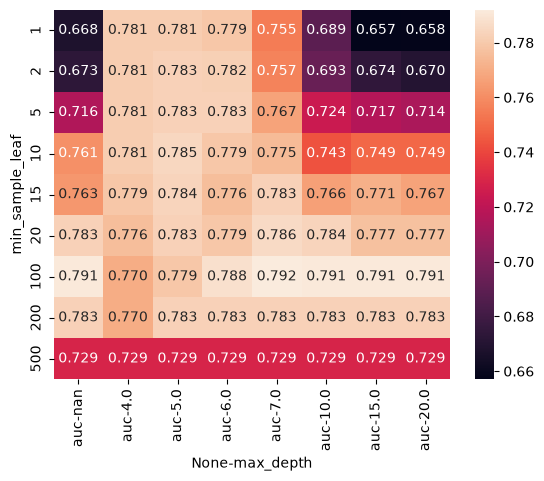

In [47]:
sns.heatmap(df_scores_pivot, annot=True, fmt='.3f')

In [48]:
dt = DecisionTreeClassifier(max_depth=7, min_samples_leaf = 100) #best according to the heatmap

## Ensembles and random forest
- Board of experts
- Ensembling models
- random forest - ensembling decision trees
- Tuning random forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
rf = RandomForestClassifier(n_estimators= 10, random_state=1) 

rf.fit(X_train,y_train)

y_pred = rf.predict_proba(X_val)[:,1]

roc_auc_score(y_val,y_pred)

0.7889594701299926

In [51]:
scores=[]

for n in range(10,201,10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train,y_train)

    y_pred = rf.predict_proba(X_val)[:,1]

    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))


In [52]:
df_scores = pd.DataFrame(scores, columns = ['n_estimators', 'auc'])

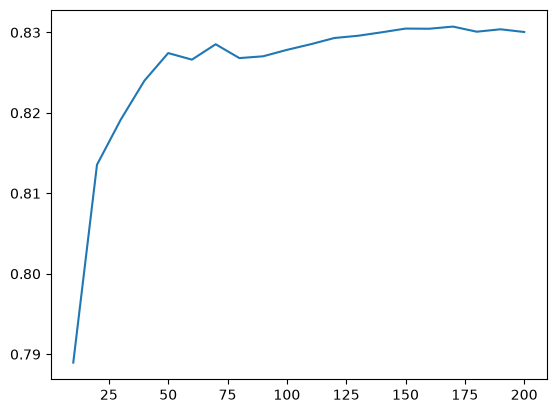

In [53]:
plt.plot(df_scores.n_estimators, df_scores.auc)

In [54]:
scores=[]

for d in [5,10,15]:
    for n in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train,y_train)

        y_pred = rf.predict_proba(X_val)[:,1]

        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))


In [55]:
cols = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns = cols)
df_scores.head()

,max_depth,n_estimators,auc
0,5,10,0.819097
1,5,20,0.822416
2,5,30,0.826779
3,5,40,0.824382
4,5,50,0.825887


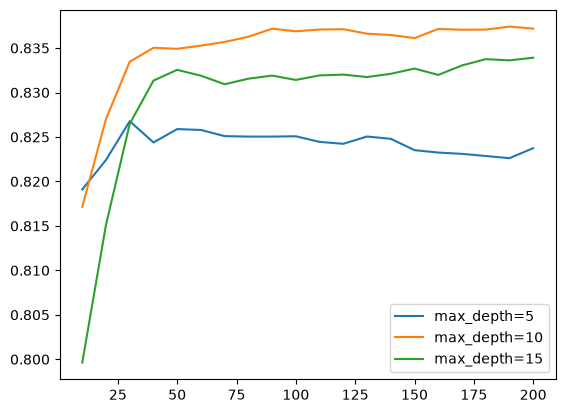

In [56]:
for d in [5,10,15]:
    df_subset=df_scores[df_scores.max_depth==d]
    plt.plot(df_subset.n_estimators, df_subset.auc, 
             label='max_depth=%d'%d)

plt.legend()


In [57]:
max_depth=10 # best max_depth

In [58]:
scores=[]

for s in [1,3,5,10,50]:
    for n in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, min_samples_leaf=s, random_state=1)
        rf.fit(X_train,y_train)

        y_pred = rf.predict_proba(X_val)[:,1]

        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

In [59]:
cols = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns = cols)
df_scores.head()

,min_samples_leaf,n_estimators,auc
0,1,10,0.817146
1,1,20,0.827022
2,1,30,0.833461
3,1,40,0.835032
4,1,50,0.834915


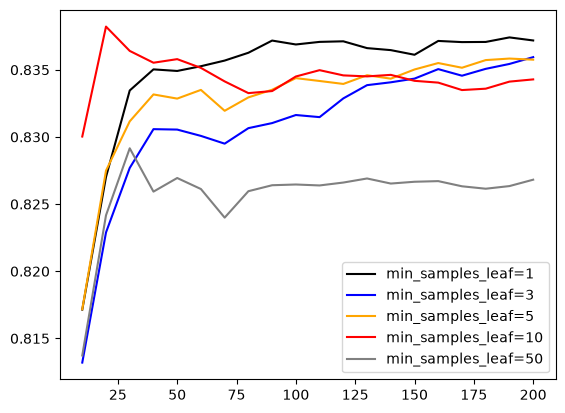

In [60]:
colors= ['black', 'blue', 'orange', 'red', 'grey']
min_samples_leaf_values = [1,3,5,10,50]


for s, color in zip(min_samples_leaf_values, colors):
    df_subset=df_scores[df_scores.min_samples_leaf==s]
    plt.plot(df_subset.n_estimators, df_subset.auc, 
             color = color,
             label='min_samples_leaf=%d'%s)

plt.legend()


In [61]:
min_samples_leaf=1

In [62]:
rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state = 1)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

Other useful parameters:
- max_features
- bootstrap

## 6.7 Gradient boosting and XGBoost
- Gradient boosting vs random forest
- installing xgboost 
- training the first model
- performance monitoring
- parsing xgboost's monitoring output

In [63]:
import xgboost as xgb

In [64]:
features = dv.get_feature_names_out()
features

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=priv',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=ukn', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

In [65]:
features = dv.get_feature_names_out()
dtrain = xgb.DMatrix(X_train, label = y_train, feature_names = list(features)) # DMatrix is a algorithm that optimize the data for training XGBoost trainig
dval = xgb.DMatrix(X_val, label=y_val, feature_names = list(features))

In [66]:
xgb_params={
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'nthreads':8,

    'seed':1,
    'verbosity':1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round = 10)

c:\Users\MSI\Documents\PROJECTS\MLZOOMCAMP\MLZoomCamp\06-trees\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:11:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "nthreads" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [67]:
y_pred = model.predict(dval)

In [68]:
roc_auc_score(y_val, y_pred)

0.8331997658640833

In [69]:
watch_list = [(dtrain, 'train'), (dval, 'val')]

In [70]:
%%capture output

xgb_params={
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread':8,
    'seed':1,
    'verbosity':1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals=watch_list)

In [71]:
s = output.stdout

In [72]:
line = s.split('\n')[0]
print(line)

[0]	train-auc:0.84883	val-auc:0.79053


In [73]:
num_iter, train_auc, val_auc = line.split('\t')

In [74]:
int(num_iter.strip('[]'))

0

In [75]:
float(train_auc.split(':')[1])

0.84883

In [76]:
float(val_auc.split(':')[1])

0.79053

In [77]:
def parse_xgb_output(output):
    results = []
    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train,val))

    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns = columns)
    return df_results

In [78]:
df_score = parse_xgb_output(output)

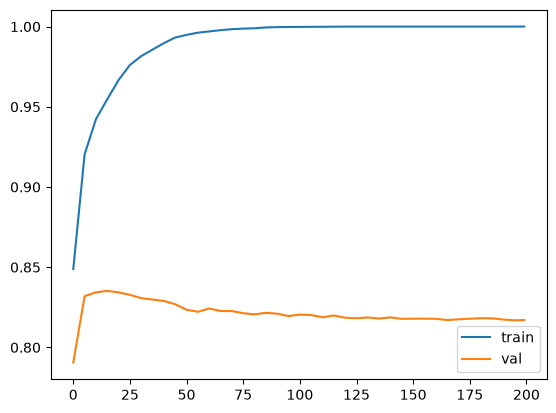

In [79]:
plt.plot(df_score.num_iter, df_score.train_auc, label = 'train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

## 6.8 XGBoost parameter tuning
- eta
- max_depth
- min_child-_weight

### Tuning eta:

In [80]:
scores = {}

In [81]:
%%capture output

xgb_params={
    'eta': 0.01,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread':8,
    'seed':1,
    'verbosity':1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals=watch_list)

In [82]:
key = 'eta=%s' %(xgb_params['eta'])
scores[key] = parse_xgb_output(output)
key 

'eta=0.01'

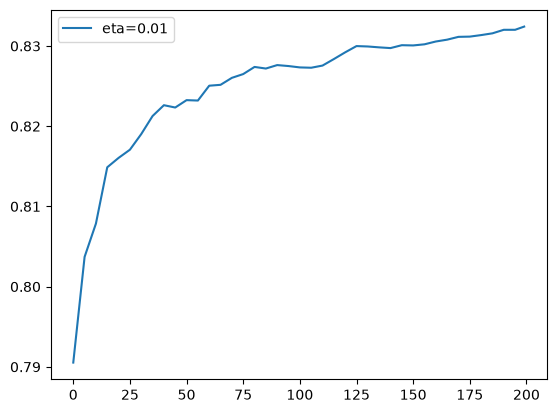

In [83]:
for key, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=key)

plt.legend()


**note: my best model is the eta = 0.3, but I'm going to use the 0.1 to keep following Alexey**

### Tuning max_depth

In [84]:
scores = {}

In [85]:
%%capture output

xgb_params={
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 1,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread':8,
    'seed':1,
    'verbosity':1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals=watch_list)

In [86]:
key = 'max_depth=%s' %(xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)
key 

'max_depth=3'

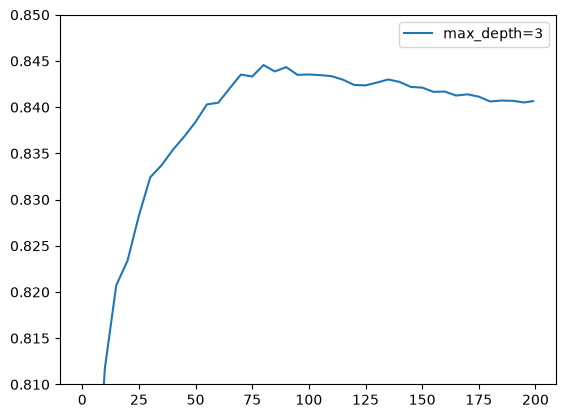

In [87]:
for key, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=key)
plt.ylim(0.81, 0.85)
plt.legend()


### Tuning min_child_weight

In [88]:
scores={}

In [89]:
%%capture output

xgb_params={
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 30,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread':8,
    'seed':1,
    'verbosity':1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round = 200, verbose_eval = 5, evals=watch_list)

In [90]:
key = 'min_child_weight=%s' %(xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)
key 

'min_child_weight=30'

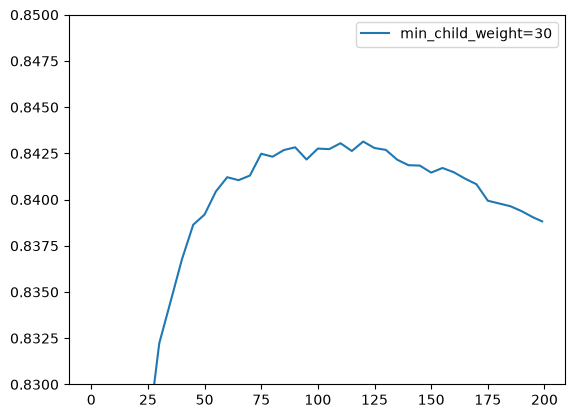

In [91]:
for key, df_score in scores.items():
    plt.plot(df_score.num_iter, df_score.val_auc, label=key)
plt.ylim(0.83, 0.85)
plt.legend()


useful parameters: 
- subsample and colsample_bytree
- lambda and alpha

## Seleting model

In [92]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [93]:
rf = RandomForestClassifier(n_estimators= 200, 
                            max_depth = 10, 
                            min_samples_leaf=3,
                            random_state=1) 

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [94]:
xgb_params={
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 30,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread':8,
    'seed':1,
    'verbosity':1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round = 175)

In [95]:
y_pred = model.predict(dval)
roc_auc_score(y_val,y_pred)

0.8398486759142496

In [96]:
df_full_train = df_full_train.reset_index(drop=True)

In [97]:
y_full_train = (df_full_train.status == 'default').astype(int).values

In [98]:
del df_full_train['status']

In [99]:
dicts_full_train = df_full_train.to_dict(orient='records')
dicts_test = df_test.to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)
X_test = dv.transform(dicts_test)

In [100]:
dtrain = xgb.DMatrix(X_full_train, label = y_full_train, feature_names = list(dv.get_feature_names_out()))
dtest = xgb.DMatrix(X_test, label = y_test, feature_names = list(dv.get_feature_names_out()))



In [101]:
xgb_params={
    'eta': 0.1,
    'max_depth': 3,
    'min_child_weight': 30,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread':8,
    'seed':1,
    'verbosity':1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round = 175)

In [102]:
y_pred = model.predict(dtest)

In [103]:
roc_auc_score(y_test, y_pred)

0.8322723718293339